<a href="https://colab.research.google.com/github/balaraji247-pixel/Guvi_Assignment_1/blob/main/Cross_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mysql-connector-python yfinance requests pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 70.0 MB/s eta 0:00:00


In [ ]:
import requests
import pandas as pd

all_data = []

for page in range(1, 3):  # adjust pages if needed
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        "vs_currency": "inr",
        "order": "market_cap_desc",
        "per_page": 250,
        "page": page,
        "sparkline": False
    }

    response = requests.get(url, params=params)
    data = response.json()
    all_data.extend(data)

df_crypto = pd.DataFrame(all_data)

df_crypto = df_crypto[
    [
        "id","symbol","name","current_price","market_cap",
        "market_cap_rank","total_volume","circulating_supply",
        "total_supply","ath","atl","last_updated"
    ]
]

df_crypto["date"] = pd.to_datetime(df_crypto["last_updated"]).dt.date
df_crypto.drop(columns=["last_updated"], inplace=True)

df_crypto.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,circulating_supply,total_supply,ath,atl,date
0,bitcoin,btc,Bitcoin,6294480.00,125974491803210,1,4.025987e+12,1.998918e+07,1.998918e+07,11187013.00,3993.420000,2026-02-14
1,ethereum,eth,Ethereum,187395.00,22636140583163,2,1.869807e+12,1.206925e+08,1.206925e+08,431946.00,28.130000,2026-02-14
2,tether,usdt,Tether,90.52,16640508802596,3,6.465014e+12,1.838170e+11,1.892839e+11,105.52,36.860000,2026-02-14
3,ripple,xrp,XRP,132.65,8086974457790,4,2.450671e+11,6.091732e+10,9.998572e+10,313.99,0.159343,2026-02-14
4,binancecoin,bnb,BNB,56858.00,7757376532409,5,1.074331e+11,1.363593e+08,1.363593e+08,121422.00,2.580000,2026-02-14


In [15]:
import mysql.connector

conn = mysql.connector.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    port=4000,
    user="4Z5hFB6ww8VYsR9.root",
    password="FzHpvkTZ17zScCXM",
    database="crypto_project"
)

cursor = conn.cursor()
print("Connected to MySQL successfully")


Connected to MySQL successfully


In [ ]:
!pip install streamlit

In [ ]:
for _, row in df_crypto.iterrows():
    row_data = row.copy()
    row_data['circulating_supply'] = round(row_data['circulating_supply'])
    row_data['total_supply'] = round(row_data['total_supply'])

    cursor.execute("""
        insert ignore into cryptocurrencies
        values (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """, tuple(row_data))

conn.commit()
print("Cryptocurrency metadata inserted")

Cryptocurrency metadata inserted


In [ ]:
top3 = df_crypto.sort_values("market_cap_rank").head(3)["id"].tolist()
print(top3)


['bitcoin', 'ethereum', 'tether']


In [ ]:
historical_data = []

for coin in top3:
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params = {"vs_currency": "inr", "days": 365}

    response = requests.get(url, params=params)

    if response.status_code == 200:
        try:
            data = response.json()["prices"]
        except requests.exceptions.JSONDecodeError:
            print(f"Error decoding JSON for {coin}. Response content: {response.text}")
            continue # Skip to the next coin if JSON is malformed
    else:
        print(f"API request failed for {coin} with status code {response.status_code}. Response content: {response.text}")
        continue # Skip to the next coin if request failed

    for item in data:
        date = pd.to_datetime(item[0], unit="ms").date()
        price = item[1]
        historical_data.append([coin, date, price])

df_prices = pd.DataFrame(historical_data, columns=["coin_id","date","price_usd"])
df_prices.head()

API request failed for tether with status code 429. Response content: Throttled



,coin_id,date,price_usd
0,bitcoin,2025-02-15,8.449166e+06
1,bitcoin,2025-02-16,8.452534e+06
2,bitcoin,2025-02-17,8.331281e+06
3,bitcoin,2025-02-18,8.318633e+06
4,bitcoin,2025-02-19,8.297395e+06


In [ ]:
for _, row in df_prices.iterrows():
    cursor.execute("""
        insert into crypto_prices
        values (%s,%s,%s)
    """, tuple(row))

conn.commit()
print("Crypto historical prices inserted")


Crypto historical prices inserted


In [ ]:
oil_url = "https://raw.githubusercontent.com/datasets/oil-prices/main/data/wti-daily.csv"
df_oil = pd.read_csv(oil_url)

df_oil["Date"] = pd.to_datetime(df_oil["Date"])
df_oil = df_oil[(df_oil["Date"] >= "2020-01-01") & (df_oil["Date"] <= "2026-01-01")]

df_oil = df_oil.rename(columns={"Date":"date","Price":"price_usd"})
df_oil.head()


,date,price_usd
8569,2020-01-02,61.17
8570,2020-01-03,63.00
8571,2020-01-06,63.27
8572,2020-01-07,62.70
8573,2020-01-08,59.65


In [ ]:
for _, row in df_oil.iterrows():
    cursor.execute("""
        INSERT INTO oil_prices
        VALUES (%s,%s)
    """, tuple(row))

conn.commit()
print("Oil data inserted")


Oil data inserted


In [ ]:
import yfinance as yf
import pandas as pd

tickers = ["^GSPC","^IXIC","^NSEI"]

stock_data = []

for ticker in tickers:
    data = yf.download(ticker, start="2020-01-01", end="2025-09-01")
    data.reset_index(inplace=True)

    data['Date'] = pd.to_datetime(data['Date']).dt.date

    for _, row in data.iterrows():
       stock_data.append([
            row["Date"].item(), # Apply .item() to 'Date' as well
            row["Open"].item(),
            row["High"].item(),
            row["Low"].item(),
            row["Close"].item(),
            row["Volume"].item(),
            ticker
        ])

df_stocks = pd.DataFrame(
    stock_data,
    columns=["date","open","high","low","close","volume","ticker"]
)

df_stocks.head()

/tmp/ipython-input-2451210162.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-09-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2451210162.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-09-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2451210162.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-09-01")
[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,volume,ticker
0,2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3459930000,^GSPC
1,2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3484700000,^GSPC
2,2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3702460000,^GSPC
3,2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3435910000,^GSPC
4,2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3726840000,^GSPC


In [ ]:
insert_query = """
    insert into stock_prices
    (date, open, high, low, close, volume, ticker)
    values (%s,%s,%s,%s,%s,%s,%s)
"""

data_to_insert = [tuple(row) for row in df_stocks.values]

cursor.executemany(insert_query, data_to_insert)

conn.commit()

print("Stock data inserted successfully 🚀")


Stock data inserted successfully 🚀


In [ ]:
for _, row in df_stocks.iterrows():
    cursor.execute("""
        insert into stock_prices
        values (%s,%s,%s,%s,%s,%s,%s)
    """, tuple(row))

conn.commit()
print("Stock data inserted")


Stock data inserted


In [ ]:
tables = ["cryptocurrencies", "crypto_prices", "oil_prices", "stock_prices"]

for table in tables:
    cursor.execute(f"select count(*) from {table}")
    count = cursor.fetchone()[0]
    print(f"{table} → {count} records")


cryptocurrencies → 500 records
crypto_prices → 732 records
oil_prices → 1500 records
stock_prices → 4248 records


In [ ]:
cursor.execute("""
select name, market_cap
from cryptocurrencies
order by market_cap desc;
""")

for row in cursor.fetchall():
    print(row)

('Bitcoin', 127462511006754)
('Ethereum', 22916373980517)
('Tether', 16639752804875)
('XRP', 8109809094850)
('BNB', 7820697088941)
('USDC', 6654090796115)
('Solana', 4479979965285)
('TRON', 2431584080244)
('Dogecoin', 1537949520386)
('Figure Heloc', 1417265952492)
('Bitcoin Cash', 1024771204346)
('WhiteBIT Coin', 1022651661114)
('Cardano', 943267996007)
('USDS', 877471548956)
('LEO Token', 716525282726)
('Hyperliquid', 692755162221)
('Monero', 592716351826)
('Chainlink', 579306841343)
('Ethena USDe', 571431727215)
('Canton', 560442319277)
('Stellar', 506014996045)
('USD1', 478889992936)
('Zcash', 419461887655)
('Hedera', 403800339840)
('Litecoin', 387772842714)
('Dai', 375220366216)
('Avalanche', 366333351003)
('PayPal USD', 364805199156)
('Sui', 350228675604)
('Shiba Inu', 348869174296)
('Toncoin', 332175716770)
('Rain', 306587612824)
('Cronos', 297626149151)
('World Liberty Financial', 261702874462)
('Tether Gold', 235753756946)
('MemeCore', 216486653926)
('PAX Gold', 208929538703)
(

In [ ]:
cursor.execute("""
select avg(current_price)
from cryptocurrencies;
""")

print("Average crypto price:", cursor.fetchone()[0])

Average crypto price: 21672.7892471980


In [ ]:
cursor.execute("""
select ticker, max(close)
from stock_prices
group by ticker;
""")

for row in cursor.fetchall():
    print(row)

('^GSPC', Decimal('6501.859863'))
('^IXIC', Decimal('21713.140625'))
('^NSEI', Decimal('26216.050781'))


In [ ]:
cursor.execute("""
select avg(price_usd)
from oil_prices;
""")

print("Average oil price:", cursor.fetchone()[0])


Average oil price: 70.2695000000


In [ ]:
cursor.execute("""
select
    cp.date,
    avg(cp.price_usd) as avg_crypto_price,
    op.price_usd as oil_price
from crypto_prices cp
join oil_prices op
on cp.date = op.date
group by cp.date;
""")

for row in cursor.fetchall():
    print(row)


(datetime.date(2025, 7, 30), Decimal('5295282.0570695000'), Decimal('71.090000'))
(datetime.date(2025, 11, 14), Decimal('4572540.1863470000'), Decimal('60.870000'))
(datetime.date(2025, 3, 6), Decimal('4032052.8883970000'), Decimal('66.620000'))
(datetime.date(2025, 12, 22), Decimal('4101428.5559755000'), Decimal('58.180000'))
(datetime.date(2025, 9, 15), Decimal('5295917.3617620000'), Decimal('63.660000'))
(datetime.date(2025, 3, 3), Decimal('4232324.3003725000'), Decimal('68.630000'))
(datetime.date(2025, 8, 19), Decimal('5262761.1702785000'), Decimal('63.380000'))
(datetime.date(2025, 7, 8), Decimal('4760340.8421745000'), Decimal('69.550000'))
(datetime.date(2025, 6, 12), Decimal('4763079.7318320000'), Decimal('68.730000'))
(datetime.date(2025, 2, 24), Decimal('4293396.2367400000'), Decimal('71.060000'))
(datetime.date(2025, 3, 20), Decimal('3836666.0848990000'), Decimal('68.550000'))
(datetime.date(2025, 6, 20), Decimal('4649675.6657325000'), Decimal('75.720000'))
(datetime.date(20

In [ ]:
query = """
select
    cp.date,
    avg(cp.price_usd) as avg_crypto,
    op.price_usd as oil_price
from crypto_prices cp
join oil_prices op
on cp.date = op.date
group by cp.date
"""

df_analysis = pd.read_sql(query, conn)


df_analysis_numeric = df_analysis.drop(columns=['date'])
print(df_analysis_numeric.corr())

/tmp/ipython-input-2748691507.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_analysis = pd.read_sql(query, conn)


            avg_crypto  oil_price
avg_crypto    1.000000   0.034172
oil_price     0.034172   1.000000


In [ ]:
cursor.execute("""
select name, symbol, market_cap
from cryptocurrencies
order by market_cap desc;
""")

for row in cursor.fetchall():
    print(row)


('Bitcoin', 'btc', 127462511006754)
('Ethereum', 'eth', 22916373980517)
('Tether', 'usdt', 16639752804875)
('XRP', 'xrp', 8109809094850)
('BNB', 'bnb', 7820697088941)
('USDC', 'usdc', 6654090796115)
('Solana', 'sol', 4479979965285)
('TRON', 'trx', 2431584080244)
('Dogecoin', 'doge', 1537949520386)
('Figure Heloc', 'figr_heloc', 1417265952492)
('Bitcoin Cash', 'bch', 1024771204346)
('WhiteBIT Coin', 'wbt', 1022651661114)
('Cardano', 'ada', 943267996007)
('USDS', 'usds', 877471548956)
('LEO Token', 'leo', 716525282726)
('Hyperliquid', 'hype', 692755162221)
('Monero', 'xmr', 592716351826)
('Chainlink', 'link', 579306841343)
('Ethena USDe', 'usde', 571431727215)
('Canton', 'cc', 560442319277)
('Stellar', 'xlm', 506014996045)
('USD1', 'usd1', 478889992936)
('Zcash', 'zec', 419461887655)
('Hedera', 'hbar', 403800339840)
('Litecoin', 'ltc', 387772842714)
('Dai', 'dai', 375220366216)
('Avalanche', 'avax', 366333351003)
('PayPal USD', 'pyusd', 364805199156)
('Sui', 'sui', 350228675604)
('Shiba 

In [ ]:
cursor.execute("""
select
    max(current_price) as highest_price,
    min(current_price) as lowest_price
from cryptocurrencies;
""")

print(cursor.fetchone())


(Decimal('6373682.000000'), Decimal('0.000000'))


In [ ]:
cursor.execute("""
select name, total_volume
from cryptocurrencies
order by total_volume desc;
""")

for row in cursor.fetchall():
    print(row)


('Tether', 6204799062483)
('Bitcoin', 3793259852019)
('Ethereum', 1733894076524)
('USDC', 620699352363)
('Solana', 334216160566)
('XRP', 237900662591)
('USD1', 128006559509)
('BNB', 104929857721)
('Dogecoin', 89989343989)
('TRON', 57274121374)
('Sui', 56165436293)
('Zcash', 46356334489)
('Bitcoin Cash', 39942766134)
('Cardano', 38224568267)
('Aave', 31915035987)
('Chainlink', 31078077818)
('Uniswap', 29879199856)
('Litecoin', 28538596724)
('Pepe', 28150124129)
('Tether Gold', 27780709557)
('PayPal USD', 26752505330)
('Bittensor', 24610549875)
('Hyperliquid', 24006478069)
('Avalanche', 20298336975)
('MANTRA', 20018762817)
('Compound', 19638643996)
('Hedera', 18357844498)
('PAX Gold', 16826760970)
('Virtuals Protocol', 16403012453)
('Aster', 15586695275)
('LayerZero', 14119389842)
('Dash', 14040036303)
('Shiba Inu', 12657800921)
('Humanity', 12598210223)
('Stellar', 11925502128)
('NEAR Protocol', 11854342019)
('Kite', 11785593391)
('Monad', 10464432272)
('World Liberty Financial', 102709

In [ ]:
cursor.execute("""
select avg(price_usd)
from oil_prices;
""")

print("Average Oil Price:", cursor.fetchone()[0])


Average Oil Price: 70.2695000000


In [ ]:
cursor.execute("""
select
    max(price_usd),
    min(price_usd)
from oil_prices;
""")

print(cursor.fetchone())


(Decimal('123.640000'), Decimal('-36.980000'))


In [ ]:
cursor.execute("""
select ticker, MAX(close)
from stock_prices
group BY ticker;
""")

for row in cursor.fetchall():
    print(row)


('^NSEI', Decimal('26216.050781'))
('^IXIC', Decimal('21713.140625'))
('^GSPC', Decimal('6501.859863'))


In [ ]:
cursor.execute("""
select ticker, avg(volume)
from stock_prices
group by ticker;
""")

for row in cursor.fetchall():
    print(row)


('^GSPC', Decimal('4456646802.5299'))
('^NSEI', Decimal('378797.7889'))
('^IXIC', Decimal('5469550520.0281'))


In [ ]:
query = """
select
    cp.date,
    avg(cp.price_usd) as avg_crypto_price,
    op.price_usd as oil_price
from crypto_prices cp
join oil_prices op
on cp.date = op.date
group by cp.date
order by cp.date;
"""

df_cross = pd.read_sql(query, conn)
df_cross.head()


/tmp/ipython-input-3206132973.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cross = pd.read_sql(query, conn)


,date,avg_crypto_price,oil_price
0,2025-02-18,4.278391e+06,72.21
1,2025-02-19,4.264670e+06,72.58
2,2025-02-20,4.312426e+06,72.88
3,2025-02-21,4.372146e+06,70.72
4,2025-02-24,4.293396e+06,71.06


In [ ]:
df_cross_numeric = df_cross.drop(columns=['date'])
print(df_cross_numeric.corr())

                  avg_crypto_price  oil_price
avg_crypto_price          1.000000   0.034172
oil_price                 0.034172   1.000000


In [ ]:
query = """
select ticker,
       (max(close) - min(close)) / min(close) * 100 as return_percentage
from stock_prices
group by ticker;
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row)


('^GSPC', Decimal('190.5989160538'))
('^IXIC', Decimal('216.4871779558'))
('^NSEI', Decimal('244.4834372195'))


In [ ]:
pip install streamlit mysql-connector-python pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 79.8 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


2026-02-15 12:39:39.478 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:39.479 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:39.481 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:39.482 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:40.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:40.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:40.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:39:40.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

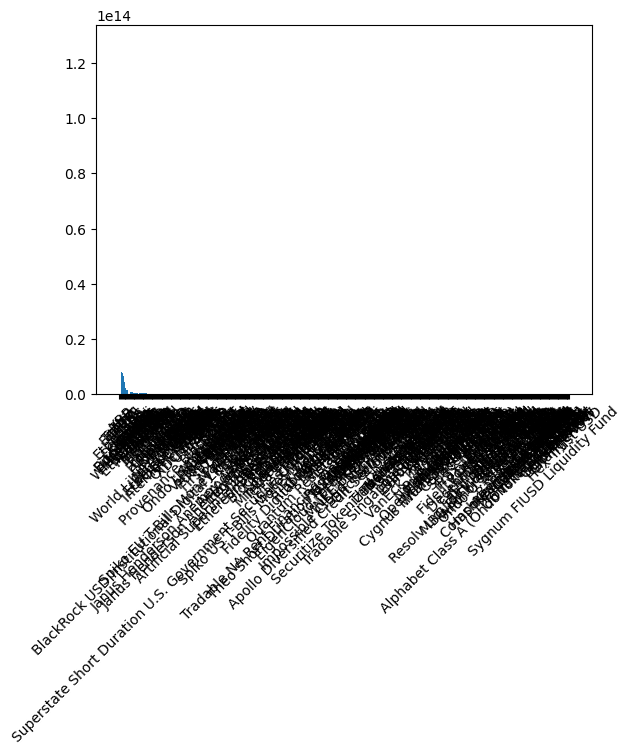

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

st.set_page_config(page_title="Cross Market Dashboard", layout="wide")

st.title("📊 Cross Market Analysis Dashboard")


conn = mysql.connector.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    port=4000,
    user="4Z5hFB6ww8VYsR9.root",
    password="FzHpvkTZ17zScCXM",
    database="crypto_project"
)

menu = st.sidebar.selectbox(
    "Select Analysis",
    ["Crypto Market", "Oil Market", "Stock Market", "Cross Market"]
)


if menu == "Crypto Market":

    query = "select name, market_cap from cryptocurrencies order by market_cap desc"
    df = pd.read_sql(query, conn)

    st.subheader("Top 10 Cryptocurrencies by Market Cap")

    fig, ax = plt.subplots()
    ax.bar(df["name"], df["market_cap"])
    plt.xticks(rotation=45)
    st.pyplot(fig)


elif menu == "Oil Market":

    query = "select date, price_usd from oil_prices"
    df = pd.read_sql(query, conn)

    st.subheader("Oil Price Trend")

    fig, ax = plt.subplots()
    ax.plot(df["date"], df["price_usd"])
    st.pyplot(fig)


elif menu == "Stock Market":

    query = "select date, close, ticker from stock_prices"
    df = pd.read_sql(query, conn)

    st.subheader("Stock Market Trend")

    ticker = st.selectbox("Select Ticker", df["ticker"].unique())
    df_filtered = df[df["ticker"] == ticker]

    fig, ax = plt.subplots()
    ax.plot(df_filtered["date"], df_filtered["close"])
    st.pyplot(fig)


elif menu == "Cross Market":

    query = """
    select
        cp.date,
        avg(cp.price_usd) as avg_crypto,
        op.price_usd as oil_price
    from crypto_prices cp
    join oil_prices op
    on cp.date = op.date
    group by cp.date
    """

    df = pd.read_sql(query, conn)

    st.subheader("Crypto vs Oil Comparison")

    fig, ax = plt.subplots()
    ax.plot(df["date"], df["avg_crypto"], label="Crypto Avg")
    ax.plot(df["date"], df["oil_price"], label="Oil Price")
    ax.legend()
    st.pyplot(fig)

In [ ]:
queries = {
    "Top 3 Crypto": "select ...",
    "Oil Highest 5Y": "select ..."
}

selected_query = st.selectbox("Choose Query", list(queries.keys()))

if st.button("Run Query"):
    df = pd.read_sql(queries[selected_query], conn)
    st.dataframe(df)


2026-02-15 12:36:42.721 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 12:36:42.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [17]:
queries = {


    "Top 3 Cryptos by Market Cap":
    """
    select name, market_cap
    from cryptocurrencies
    order by market_cap DESC
    limit 3
    """,

    "Coins with Circulating Supply > 90%":
    """
    select name, circulating_supply, total_supply
    from cryptocurrencies
    where circulating_supply >= 0.9 * total_supply
    """,

    "Coins Within 10% of ATH":
    """
    select name, current_price, ath
    from cryptocurrencies
    where current_price >= 0.9 * ath
    """,

    "Average Market Cap Rank (Volume > $1B)":
    """
    select avg(market_cap_rank) as avg_rank
    from cryptocurrencies
    where total_volume > 1000000000
    """,

    "Most Recently Updated Coin":
    """
    select *
    from cryptocurrencies
    order by date desc
    limit 1
    """,


    "Bitcoin Highest Price (1 Year)":
    """
    select max(price_usd) AS highest_price
    from crypto_prices
    where coin_id = 'bitcoin'
    and date >= curdate() - interval 365 day
    """,

    "Ethereum Average Price (1 Year)":
    """
    select avg(price_usd) as eth_avg_price
    from crypto_prices
    where coin_id = 'ethereum'
    and date >= curdate() - interval 365 day
    """,

    "Coin with Highest Avg Price (1 Year)":
    """
    select coin_id, avg(price_usd) as avg_price
    from crypto_prices
    where date >= curdate() - interval 365 day
    group by coin_id
    order by avg_price desc
    limit 1
    """,


    "Highest Oil Price (5 Years)":
    """
    select max(price_usd) as highest_oil
    from oil_prices
    where date >= curdate() - interval 5 year
    """,

    "Average Oil Price Per Year":
    """
    select year(date) as year, avg(price_usd) as avg_price
    from oil_prices
    group by year(date)
    order by year
    """,

    "Lowest Oil Price (10 Years)":
    """
    select min(price_usd) as lowest_price
    from oil_prices
    where date >= curdate() - interval 10 year
    """,

    "Oil Volatility Per Year (Max-Min)":
    """
    select year(date) as year,
           max(price_usd) - min(price_usd) as volatility
    from oil_prices
    group by year(date)
    order by year
    """,


    "Highest NASDAQ Close":
    """
    select max(close) as highest_nasdaq
    from stock_prices
    where ticker = '^IXIC'
    """,

    "Top 5 S&P 500 High-Low Spread Days":
    """
    select date, high - low as price_difference
    from stock_prices
    where ticker = '^GSPC'
    order by price_difference desc
    limit 5
    """,

    "Monthly Average Closing Price (All Tickers)":
    """
    selewct ticker,
           year(date) as year,
           month(date) as month,
           avg(close) as avg_close
    from stock_prices
    group by ticker, year(date), month(date)
    order by ticker, year, month
    """,

    "Average NSEI Volume (2024)":
    """
    select avg(volume) as avg_volume_2024
    from stock_prices
    where ticker = '^NSEI'
    and year(date) = 2024
    """,


    "Bitcoin vs Oil Avg Price (2025)":
    """
    select
        avg(c.price_usd) as bitcoin_avg,
        avg(o.price_usd) as oil_avg
    from crypto_prices c
    join oil_prices o on c.date = o.date
    where c.coin_id = 'bitcoin'
    and year(c.date) = 2025
    """,

    "Bitcoin vs S&P 500 Daily Comparison (2025)":
    """
    select c.date,
           c.price_usd AS bitcoin_price,
           s.close AS sp500_close
    from crypto_prices c
    join stock_prices s on c.date = s.date
    where c.coin_id = 'bitcoin'
    and s.ticker = '^GSPC'
    and year(c.date) = 2025
    """,

    "Ethereum vs NASDAQ (2025)":
    """
    select c.date,
           c.price_usd AS ethereum_price,
           s.close AS nasdaq_close
    from crypto_prices c
    join stock_prices s on c.date = s.date
    where c.coin_id = 'ethereum'
    and s.ticker = '^IXIC'
    and year(c.date) = 2025
    """,

    "Multi-Market Daily Comparison":
    """
    select c.date,
           c.price_usd AS bitcoin_price,
           o.price_usd AS oil_price,
           s.close AS sp500_close
    from crypto_prices c
    join oil_prices o on c.date = o.date
    join stock_prices s on c.date = s.date and s.ticker = '^GSPC'
    where c.coin_id = 'bitcoin'
    order by c.date
    """
}
